C:\Users\sanja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,809 (218.00 KB)

 Trainable params: 55,041 (215.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3682 - mae: 0.4662 - val_loss: 0.2227 - val_mae: 0.4544 - learning_rate: 0.0010
Epoch 2/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1486 - mae: 0.3045 - val_loss: 0.1774 - val_mae: 0.4062 - learning_rate: 0.0010
Epoch 3/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0848 - mae: 0.2276 - val_loss: 0.1141 - val_mae: 0.3191 - learning_rate: 0.0010
Epoch 4/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0656 - mae: 0.2011 - val_loss: 0.1057 - val_mae: 0.3090 - learning_rate: 0.0010
Epoch 5/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0544 - mae: 0.1863 - val_loss: 0.1033 - val_mae: 0.3034 - learning_rate: 0.0010
Epoch 6/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0476 - mae: 0.1687 - val_loss: 0.0772 - val_mae: 0.2532 - learning_rate: 0.0010
Epoch 7/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0380 - mae: 0.1506 - val_loss: 0.0666 - val_mae: 0.2311 - learning_rate: 0.0010
Epoch 8/300


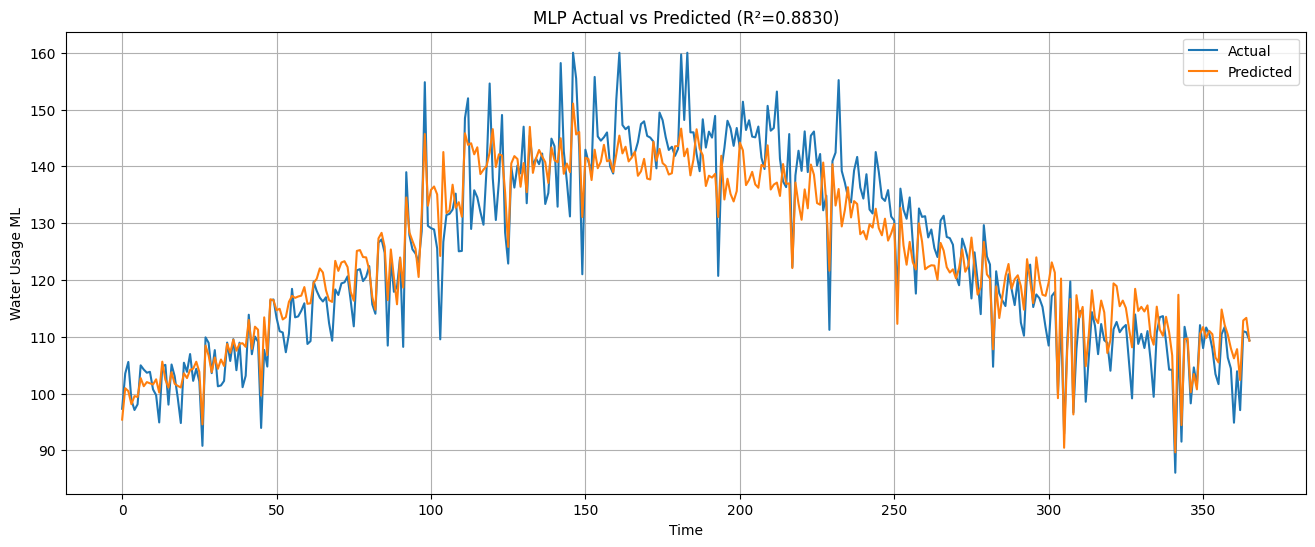

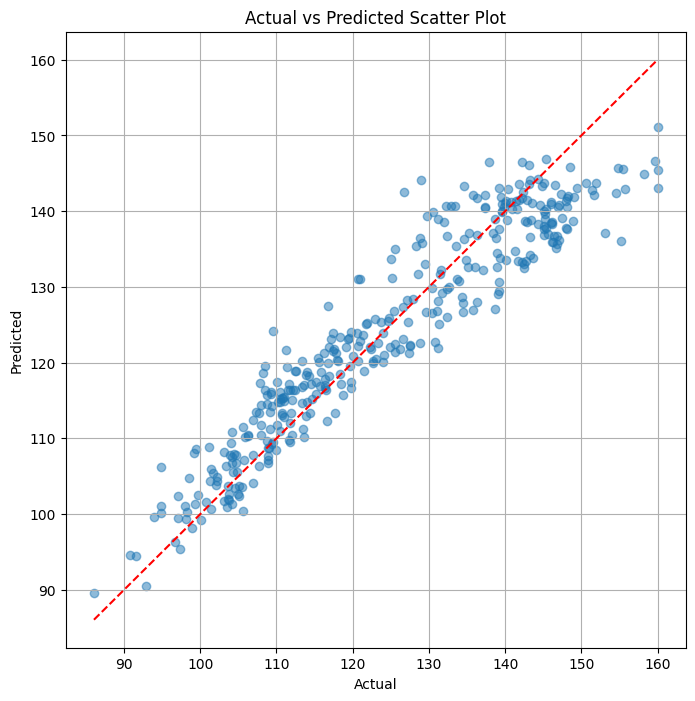

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("water_consumption_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.sort_values("Date", inplace=True)

df.reset_index(drop=True, inplace=True)

target = "Total_Daily_Usage_ML"

# =====================================================
# CYCLICAL FEATURES
# =====================================================

df['month_sin'] = np.sin(
    2*np.pi*df['Month']/12
)

df['month_cos'] = np.cos(
    2*np.pi*df['Month']/12
)

df['day_sin'] = np.sin(
    2*np.pi*df['Day_of_Year']/365
)

df['day_cos'] = np.cos(
    2*np.pi*df['Day_of_Year']/365
)

# =====================================================
# LAG FEATURES
# =====================================================

for lag in [1,2,3,4,5,7,14,21,30,60,90,180,365]:
    df[f'lag_{lag}'] = df[target].shift(lag)

# =====================================================
# MOVING AVERAGES
# =====================================================

df['ma_7'] = df[target].rolling(7).mean()

df['ma_30'] = df[target].rolling(30).mean()

# =====================================================
# STANDARD DEVIATION
# =====================================================

df['std_7'] = df[target].rolling(7).std()

df['std_30'] = df[target].rolling(30).std()

# =====================================================
# EMA
# =====================================================

df['ema_7'] = df[target].ewm(span=7).mean()

df['ema_30'] = df[target].ewm(span=30).mean()

# =====================================================
# TREND FEATURES
# =====================================================

df['diff_1'] = df[target].diff(1)

df['diff_7'] = df[target].diff(7)

# =====================================================
# PERCENT CHANGE
# =====================================================

df['pct_change_1'] = df[target].pct_change()

df['pct_change_7'] = df[target].pct_change(7)

# =====================================================
# REMOVE NULLS
# =====================================================

df.dropna(inplace=True)

# =====================================================
# FEATURES
# =====================================================

features = [

    'Day_of_Week',
    'Month',
    'Year',
    'Day_of_Year',

    'Is_Weekend',
    'Holiday_Flag',

    'Temperature_C',
    'Rainfall_mm',
    'Humidity_pct',
    'Evaporation_Rate_mm',

    'Population',
    'Household_Count',
    'Urbanization_Index',

    'Pump_Status',

    'Reservoir_Level_pct',

    'month_sin',
    'month_cos',

    'day_sin',
    'day_cos',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',
    'lag_60',
    'lag_90',
    'lag_180',
    'lag_365',

    'ma_7',
    'ma_30',

    'std_7',
    'std_30',

    'ema_7',
    'ema_30',

    'diff_1',
    'diff_7',

    'pct_change_1',
    'pct_change_7'
]

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

split = int(len(df) * 0.8)

train_df = df.iloc[:split]

test_df = df.iloc[split:]

# =====================================================
# SCALING
# =====================================================

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X_train = feature_scaler.fit_transform(
    train_df[features]
)

X_test = feature_scaler.transform(
    test_df[features]
)

y_train = target_scaler.fit_transform(
    train_df[[target]]
)

y_test = target_scaler.transform(
    test_df[[target]]
)

# =====================================================
# MLP MODEL
# =====================================================

model = Sequential()

model.add(
    Dense(
        256,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.2))

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(Dropout(0.2))

model.add(
    Dense(
        32,
        activation='relu'
    )
)

model.add(Dense(1))

# =====================================================
# COMPILE
# =====================================================

model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss='mse',

    metrics=['mae']
)

model.summary()

# =====================================================
# CALLBACKS
# =====================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=20,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1
)

# =====================================================
# TRAIN
# =====================================================

history = model.fit(

    X_train,

    y_train,

    validation_split=0.1,

    epochs=300,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

# =====================================================
# PREDICT
# =====================================================

predictions = model.predict(
    X_test
)

predictions_actual = (
    target_scaler.inverse_transform(
        predictions
    )
)

y_test_actual = (
    target_scaler.inverse_transform(
        y_test
    )
)

# =====================================================
# METRICS
# =====================================================

mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("\nRESULTS")
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

# =====================================================
# ACTUAL VS PREDICTED
# =====================================================

plt.figure(figsize=(16,6))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    predictions_actual,
    label='Predicted'
)

plt.title(
    f'MLP Actual vs Predicted (R²={r2:.4f})'
)

plt.xlabel("Time")

plt.ylabel("Water Usage ML")

plt.legend()

plt.grid(True)

plt.show()

# =====================================================
# SCATTER PLOT
# =====================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test_actual,
    predictions_actual,
    alpha=0.5
)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--'
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Scatter Plot"
)

plt.grid(True)

plt.show()

In [2]:
model.save("mlp_model.keras")

2.21.0
3.14.1
